1. PROBLEM STATEMENT

“The Google Play Store dataset contains information about apps, including ratings, reviews, installs, and categories. However, the data is unclean, inconsistent, and does not directly provide meaningful insights. Therefore, data preprocessing and analysis are required to understand app performance, user preferences, and factors influencing app success.”

2. OBJECTIVE

“The objective of this project is to clean and analyze Google Play Store data using Python to identify key patterns, evaluate app performance, and generate insights that support data-driven decision making.”

**Queries:**

1. Which app categories have the highest number of apps in the Play Store?

2. Which app categories have the highest average ratings?

3. Which app categories have the highest number of installs?

4. Are free apps more popular than paid apps?

5. How does app price affect the number of installs?

6. Do apps with more installs also have better ratings?

7. Do apps with more reviews also have more installs?

8. Which content rating group has the highest number of apps?

9. Does app size influence the number of installs?

10. Do recently updated apps perform better than outdated apps

3. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

4. Load dataset

In [ ]:
df = pd.read_csv('googleplaystore.csv')

5. Data Understanding

In [ ]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:
df.shape # No of rows & columns

(9660, 14)

In [ ]:
df.describe() # also use include='all' to calculate statistics of both categorical and Numerical columns

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [ ]:
df.isnull().sum()

,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


6. Data Cleaning


Handle Missing Values

In [ ]:
missing_percent = (df.isnull().sum() / len(df)) * 100  # calculate null values percentage for replacing or dropping null values
print(missing_percent)

App                0.000000
Category           0.000000
Rating            13.596532
Reviews            0.000000
Size               0.000000
Installs           0.000000
Type               0.009224
Price              0.000000
Content Rating     0.009224
Genres             0.000000
Last Updated       0.000000
Current Ver        0.073794
Android Ver        0.027673
dtype: float64


In [ ]:
df['Rating'].fillna(df['Rating'].median(), inplace=True)

/tmp/ipykernel_2663/3537473122.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [ ]:
df['Type'].fillna(df['Type'].mode()[0], inplace=True)

/tmp/ipykernel_2663/1142660726.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [ ]:
df['Content Rating'].fillna("Everyone", inplace=True)

/tmp/ipykernel_2663/2476750429.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





Fix Installs Column

In [ ]:
df['Installs'] = df['Installs'].astype(str).str.replace('[+,]', '', regex=True)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')
df['Installs'] = df['Installs'].fillna(0).astype(int)

Fix Price Column

In [ ]:
df['Price'] = df['Price'].str.replace('$', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Price'] = df['Price'].fillna(0)

In [ ]:
# Fix Reviews
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# Fix Rating
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

In [ ]:
df.fillna(0, inplace=True)

Handle and Remove Duplicates

In [ ]:
df.duplicated().sum()

np.int64(483)

In [ ]:
df.drop_duplicates(subset='App', keep='last', inplace=True)

In [ ]:
# Re-check duplicate values
df.duplicated().sum()

np.int64(0)

7. Outlier Handling

In [ ]:
cols = ['Rating', 'Reviews', 'Installs']

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] > upper, upper, df[col])
    df[col] = np.where(df[col] < lower, lower, df[col])

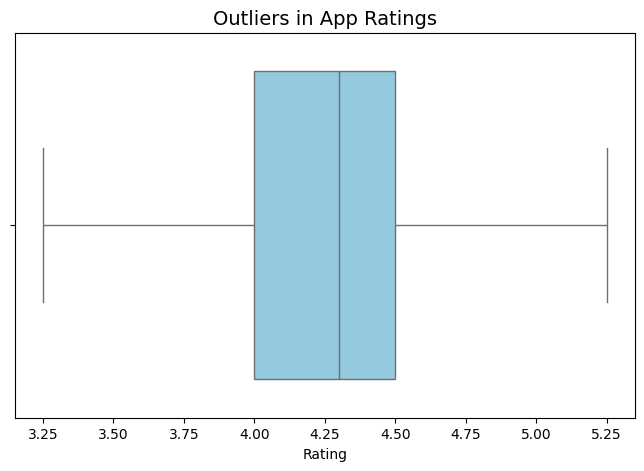

In [ ]:
# Outlier Handled and visually displayed
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x=df['Rating'], color='skyblue')
plt.title("Outliers in App Ratings", fontsize=14)
plt.xlabel("Rating")
plt.show()

8. FEATURE ENGINEERING

🔹 App Popularity Score

In [ ]:
df['Popularity_Score'] = df['Rating'] * df['Installs']

In [ ]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Popularity_Score
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19M,10000.0,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,41000.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,73447.5,8.7M,2498500.0,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,11742950.0
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,73447.5,25M,2498500.0,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,11243250.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8M,100000.0,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,430000.0
5,Paper flowers instructions,ART_AND_DESIGN,4.4,167.0,5.6M,50000.0,Free,0.0,Everyone,Art & Design,"March 26, 2017",1.0,2.3 and up,220000.0


EDA (EXPLORATORY DATA ANALYSIS)

**1,Which app categories have the highest number of apps in the Play Store?**

In [ ]:
category_count = df['Category'].value_counts().head(10).reset_index()
category_count.columns = ['Category', 'Count']

fig = px.bar(
    category_count,
    x='Category',
    y='Count',
    color='Count',
    color_continuous_scale='Viridis',
    title='Top 10 App Categories by Number of Apps',
    text='Count'
)

fig.update_layout(
    title_x=0.5,
    xaxis_title='Category',
    yaxis_title='Number of Apps',
    template='plotly_white'
)

fig.update_traces(textposition='outside')
fig.show()

**Insights:**

Few categories dominate (e.g., Games, Tools)

Market is crowded in popular categories

**Recommendations:**

Target less competitive categories

Differentiate features in crowded markets

**2,Which app categories have the highest average ratings?**

In [ ]:
avg_rating = df.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(10).reset_index()

fig = px.bar(
    avg_rating,
    x='Category',
    y='Rating',
    color='Rating',
    color_continuous_scale='Plasma',
    title='Top 10 Categories by Average Rating',
    text=avg_rating['Rating'].round(2)
)

fig.update_layout(
    title_x=0.5,
    xaxis_title='Category',
    yaxis_title='Average Rating',
    template='plotly_white'
)

fig.update_traces(textposition='outside')
fig.show()

**Insights:**

Some niche categories have higher ratings

Popular categories may not have best quality

**Recommendations:**

Focus on quality over quantity

Improve user experience

**3,Which app categories have the highest number of installs?**

In [ ]:
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')
df['Installs'] = df['Installs'].fillna(0)

cat_installs = df.groupby('Category')['Installs'].mean().reset_index()

fig = px.bar(cat_installs,
             x='Category', y='Installs',
             color='Installs',
             title="Average Installs by Category",
             color_continuous_scale='inferno')
fig.update_layout(xaxis_tickangle=90)
fig.show()

**Insights:**

Certain categories attract more users

High demand sectors exist

**Recommendations:**

Invest in high-demand categories

Analyze user needs

**4,Are free apps more popular than paid apps?**

In [ ]:
type_count = df['Type'].value_counts().reset_index()
type_count.columns = ['Type', 'Count']

fig = px.pie(
    type_count,
    names='Type',
    values='Count',
    hole=0.45,
    title='Free vs Paid Apps Distribution',
    color='Type',
    color_discrete_sequence=px.colors.sequential.RdBu
)

fig.update_layout(title_x=0.5)
fig.show()

**Insights**

Free apps dominate the Play Store.

Users prefer apps with no initial cost.

**Recommendations**

Developers can use a freemium model.

Offer basic features for free and advanced features as premium.

**5,How does app price affect the number of installs?**

In [ ]:
paid_apps = df[(df['Type'] == 'Paid') & (df['Price'] > 0) & (df['Installs'] > 0)]

fig = px.scatter(
    paid_apps,
    x='Price',
    y='Installs',
    size='Reviews',
    color='Rating',
    hover_name='App',
    color_continuous_scale='Magma',
    title='Price vs Installs for Paid Apps'
)

fig.update_layout(
    title_x=0.5,
    xaxis_title='Price ($)',
    yaxis_title='Installs',
    template='plotly_white'
)

fig.show()

**Insights:**

Higher price → fewer installs

Free apps dominate

**Recommendations:**

Keep pricing competitive

Offer trials or free versions

**6,Do apps with more installs also have better ratings?**

In [ ]:
fig = px.scatter(
    df,
    x='Installs',
    y='Rating',
    size='Reviews',
    color='Rating',
    hover_name='App',
    color_continuous_scale='Cividis',
    title='Installs vs Rating'
)

fig.update_layout(
    title_x=0.5,
    xaxis_title='Installs',
    yaxis_title='Rating',
    template='plotly_white'
)

fig.show()

**Insights:**

No strong direct relationship

Popular apps don’t always have highest ratings

**Recommendations:**

Focus on user satisfaction, not just downloads

**7,Do apps with more reviews also have more installs?**

In [ ]:
fig = px.scatter(df,
                 x='Reviews', y='Installs',
                 color='Category',
                 title="Reviews vs Installs")
fig.show()

**Insights:**

Strong positive relationship

More reviews → more installs

**Recommendations:**

Encourage user feedback & reviews

Improve engagement

**8,Which content rating group has the highest number of apps?**

In [ ]:
content_count = df['Content Rating'].value_counts().reset_index()
content_count.columns = ['Content Rating', 'Count']

fig = px.bar(
    content_count,
    x='Content Rating',
    y='Count',
    color='Count',
    color_continuous_scale='Sunset',
    title='App Count by Content Rating',
    text='Count'
)

fig.update_layout(
    title_x=0.5,
    xaxis_title='Content Rating',
    yaxis_title='Number of Apps',
    template='plotly_white'
)

fig.update_traces(textposition='outside')
fig.show()

**Insight**

Most apps fall under Everyone.

This means the Play Store mainly targets a general audience.

**Recommendation**

Developers targeting mass users should build apps suitable for all age groups.

Niche audiences can still be valuable if content is specific.

**9,Does app size influence the number of installs?**

In [ ]:
# Function to clean and convert 'Size' to 'Size_MB'
def clean_size(size_str):
    size_str = str(size_str).strip().replace(',', '') # Ensure string and remove commas
    if 'M' in size_str:
        # Convert 'M' (Megabytes) values to float
        return pd.to_numeric(size_str.replace('M', ''), errors='coerce')
    elif 'k' in size_str:
        # Convert 'k' (Kilobytes) values to float and then to MB
        return pd.to_numeric(size_str.replace('k', ''), errors='coerce') / 1024
    # For 'Varies with device' or any other non-numeric string, coerce to NaN
    return pd.to_numeric(size_str, errors='coerce')

# Apply the cleaning function and fill any resulting NaN values (from 'Varies with device' or other errors) with 0
df['Size_MB'] = df['Size'].apply(clean_size).fillna(0)

# Now proceed with plotting, as 'Size_MB' should be numeric
size_df = df[(df['Size_MB'].notna()) & (df['Installs'].notna())]

fig = px.scatter(
    size_df,
    x='Size_MB',
    y='Installs',
    size='Reviews',
    color='Rating',
    hover_name='App',
    color_continuous_scale='Tealgrn',
    title='App Size vs Installs'
)

fig.update_layout(
    title_x=0.5,
    xaxis_title='App Size (MB)',
    yaxis_title='Installs',
    template='plotly_white'
)

fig.show()

**Insight**

Very large apps may not always perform well.

Smaller and optimized apps can still attract many users.

**Recommendation**

Developers should optimize app size for better accessibility.

Lightweight apps are better for mobile users with limited storage/data.

**10,Do recently updated apps perform better than outdated apps**

In [ ]:
recent_apps = df[df['Last Updated'].notna()].copy()
recent_apps['Last Updated'] = pd.to_datetime(recent_apps['Last Updated'], errors='coerce')
recent_apps.dropna(subset=['Last Updated'], inplace=True)
recent_apps['Year Updated'] = recent_apps['Last Updated'].dt.year

update_perf = recent_apps.groupby('Year Updated').agg({
    'Rating': 'mean',
    'App': 'count'
}).reset_index()

update_perf.columns = ['Year Updated', 'Average Rating', 'App Count']

fig = px.bar(
    update_perf,
    x='Year Updated',
    y='Average Rating',
    color='Average Rating',
    text=update_perf['Average Rating'].round(2),
    hover_data=['App Count'],
    title='Average Rating by Year Updated',
    color_continuous_scale='Plasma'
)

fig.update_traces(
    textposition='outside',
    marker_line_width=1.5,
    marker_line_color='black'
)

fig.update_layout(
    title_x=0.5,
    xaxis_title='Year Updated',
    yaxis_title='Average Rating',
    template='plotly_white',
    hovermode='x unified'
)

fig.show()

11. What is the relationship between different numerical features in the dataset?

In [ ]:
import plotly.express as px

# Correlation matrix using Heatmap
corr = df.corr(numeric_only=True)

fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    title="Correlation Heatmap of Numerical Features"
)

fig.show()

12. How do multiple numerical features relate to each other in the dataset?

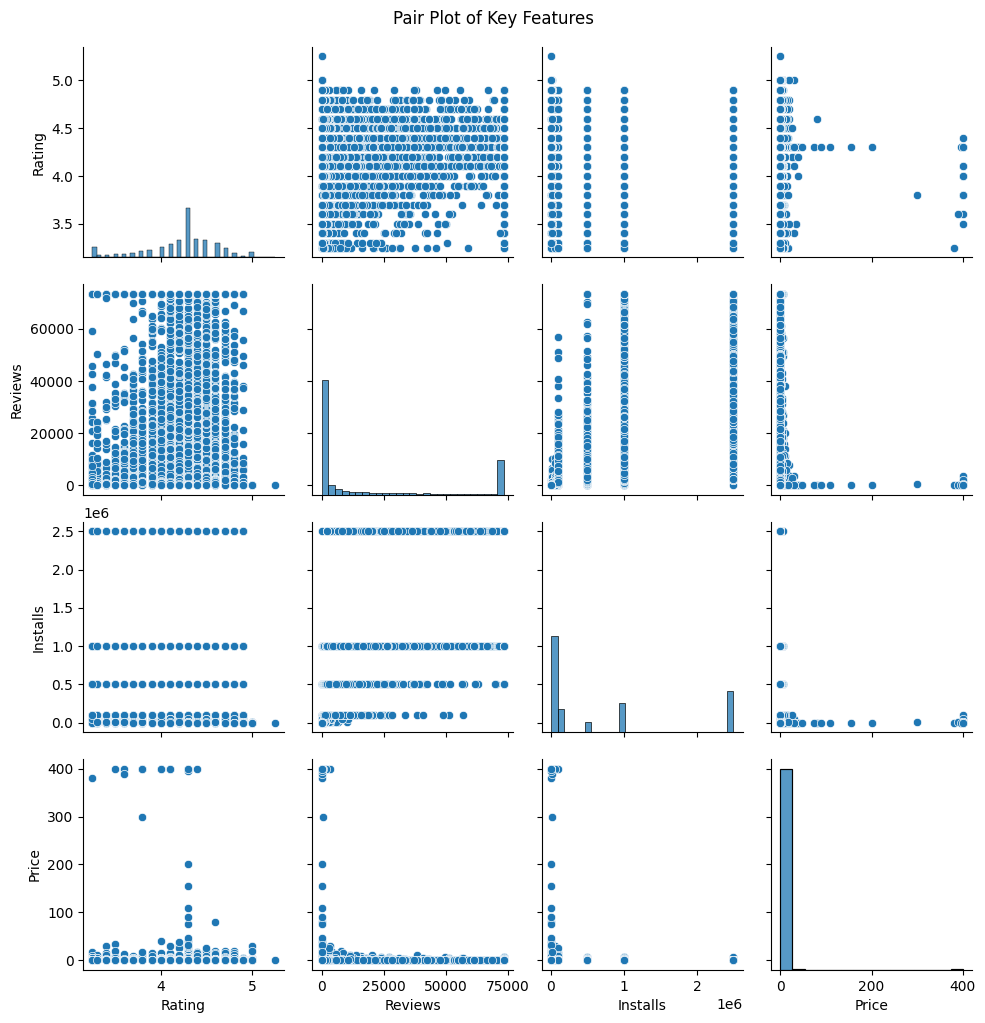

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df[['Rating','Reviews','Installs','Price']])
plt.suptitle("Pair Plot of Key Features", y=1.02)
plt.show()

**Insight**

These apps dominate user attention and market reach.

Popular apps often combine strong utility, trust, and accessibility.

**Recommendation**

Study these apps to understand successful features and user expectations.

**OVERALL INSIGHTS**

1. Free Apps Dominate

“From the analysis, we can see that most apps are free, and they attract more installs compared to paid apps. This shows that users prefer free applications.”

2. High Competition in Popular Categories

“Categories like Games and Tools have the highest number of apps, which means there is high competition in these areas.”

3. Reviews Drive Installs

“There is a strong relationship between reviews and installs. Apps with more reviews tend to have more installs, showing that user engagement plays an important role.”

4. Ratings vs Installs

“Although most apps have high ratings, there is no strong connection between ratings and installs. So, more downloads do not always mean better ratings.”

5. Importance of Updates

“Apps that are updated regularly perform better than outdated apps. This shows that continuous improvement is important.”

**OVERALL RECOMMENDATIONS**

1. Use Freemium Model

“Developers should adopt a freemium model, where apps are free but include ads or in-app purchases to maximize user reach.”

2. Improve User Engagement

“It is important to encourage users to give reviews and feedback, as this helps increase app visibility and installs.”

3. Choose Categories Wisely

“Developers should either choose less competitive categories or bring innovation into popular ones.”

4. Maintain Quality

“Maintaining app quality and performance is essential to keep ratings high and users satisfied.”

5. Update Regularly

“Regular updates help in fixing issues, adding new features, and retaining users.”